0 计算出每组所需的最小样本量

In [9]:
import statsmodels.stats.power as ssp
import statsmodels.stats.proportion as ssproption  
PA = 0.12
PB = 0.13
# 计算效应量 (Effect Size)
effect_size = ssproption.proportion_effectsize(PB, PA) 

# 计算单组所需最小样本量
sample_n = ssp.NormalIndPower().solve_power(effect_size, 
                                            power=0.8, 
                                            alpha=0.05, 
                                            ratio=1)

# 打印结果（向上取整）
import math
print(f"基线: {PA}, 目标: {PB}")
print(f"计算出的效应量 (Effect Size): {effect_size:.4f}")
print(f"每组所需最小样本量: {math.ceil(sample_n)} 人")
print(f"实验总计所需最小样本量（两组相加）: {math.ceil(sample_n) * 2} 人")

基线: 0.12, 目标: 0.13
计算出的效应量 (Effect Size): 0.0302
每组所需最小样本量: 17164 人
实验总计所需最小样本量（两组相加）: 34328 人


# 数据导入与分流交叉检验

In [2]:
import pymysql
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.stats.proportion as ssp

# 1. 创建连接并读取数据
connector = pymysql.connect(host='localhost', 
                            user='root', 
                            password='123456', 
                            database='2page_abtest', 
                            charset='utf8')
df = pd.read_sql('select * from df_abtest where group_type != "no_effective"', 
                 con=connector)

# 2. 交叉表检验
print(pd.crosstab(df['group_type'], df['page_type']))

C:\Users\11714\AppData\Local\Temp\ipykernel_4108\4038015380.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql('select * from df_abtest where group_type != "no_effective"',


page_type   new_page  old_page
group_type                    
control_1          0     88095
control_2          0     39339
treatment      39244         0


执行结果证实，control_1与control_2全为old_page，treatment全为new_page，分流逻辑正确。

# 数据完整性检验：样本比例失衡（SRM）检查

In [4]:
from scipy.stats import chisquare

# 提取AB测试阶段的实际样本量
n_control = df[df['group_type'] == 'control_2'].shape[0]
n_treatment = df[df['group_type'] == 'treatment'].shape[0]

observed = [n_control, n_treatment]
expected = [sum(observed) / 2, sum(observed) / 2]

# 卡方检验
chi2_stat, srm_p_val = chisquare(f_obs=observed, f_exp=expected)
print(f"SRM检验 P值: {srm_p_val:.4f}")

print("若 p_val > 0.05，则说明无样本比例失衡异常，可继续实验")

SRM检验 P值: 0.7347
若 p_val > 0.05，则说明无样本比例失衡异常，可继续实验


# A/A Test 验证（系统公平性校验）

为确保实验组和对照组的本底无差异，从 control_1 和 control_2 中各无放回抽样 sample_n（17,164条）数据进行 Z 检验。

In [11]:
from statsmodels.stats.power import zt_ind_solve_power
# 确定抽样量并抽样
N_size = int(np.ceil(sample_n))
aa_control_1 = df[df['group_type']=='control_1'].sample(n=N_size, random_state=42)
aa_control_2 = df[df['group_type']=='control_2'].sample(n=N_size, random_state=42)

# 聚合统计
aa_test = pd.concat([aa_control_2, aa_control_1]).reset_index(drop=True)
print(aa_test.groupby('group_type')['if_convert'].agg(['mean', 'count']))

# Z检验与置信区间
success_aa = [aa_control_2['if_convert'].sum(), aa_control_1['if_convert'].sum()]

import statsmodels.stats.proportion as sms_prop
z_stat_aa, p_val_aa = sms_prop.proportions_ztest(success_aa, nobs=[N_size, N_size])
ci_aa = sms_prop.proportion_confint(success_aa, nobs=[N_size, N_size], alpha=0.05)

print(f"A/A Test Z统计量: {z_stat_aa:.4f}, P值: {p_val_aa:.4f}")

                mean  count
group_type                 
control_1   0.118038  17164
control_2   0.121766  17164
A/A Test Z统计量: 1.0634, P值: 0.2876


A/A测试结论：P值显著大于 0.05。无法拒绝原假设，说明在实验前，两个相互独立的对照组在基准转化率上无统计学显著差异。分流系统均匀、平稳，可以正式进行 A/B 测试。

# A/B Test 核心统计结论

使用相同的抽样策略，对后半月的 control_2（旧页面）与 treatment（新页面）进行双样本比例 Z 检验。

In [12]:
# 抽样提取AB测试样本
ab_control = df[df['group_type']=='control_2'].sample(n=N_size, random_state=42)
ab_treatment = df[df['group_type']=='treatment'].sample(n=N_size, random_state=42)

# 计算核心指标均值
ab_test = pd.concat([ab_control, ab_treatment]).reset_index(drop=True)
conv_summary = ab_test.groupby('group_type')['if_convert'].agg(['mean', 'std'])
print(conv_summary)

# 假设检验
success_ab = [ab_control['if_convert'].sum(), ab_treatment['if_convert'].sum()]

import statsmodels.stats.proportion as sms_prop
z_stat_ab, p_val_ab = sms_prop.proportions_ztest(success_ab, nobs=[N_size, N_size])
(lower_con, lower_treat), (upper_con, upper_treat) = sms_prop.proportion_confint(success_ab, nobs=[N_size, N_size], alpha=0.05)
print(f'A/B Test Z统计量: {z_stat_ab:.4f}')
print(f'A/B Test P值 (p-value): {p_val_ab:.4f}')
print(f'对照组 95% 置信区间: [{lower_con:.4f}, {upper_con:.4f}]')
print(f'实验组 95% 置信区间: [{lower_treat:.4f}, {upper_treat:.4f}]')

                mean       std
group_type                    
control_2   0.121766  0.327025
treatment   0.121300  0.326486
A/B Test Z统计量: 0.1321
A/B Test P值 (p-value): 0.8949
对照组 95% 置信区间: [0.1169, 0.1267]
实验组 95% 置信区间: [0.1164, 0.1262]


In [16]:
#实验结论
print("\n" + "="*30 + " 实验统计学结论 " + "="*30)
alpha = 0.05
if p_val_ab < alpha:
    print(f"结论：【显著胜出！】P值为 {p_val_ab:.4f} < {alpha}，拒绝原假设。")
    print(f"新版页面与旧版页面存在显著差异。实验组转化率均值为 {conv_summary.loc['treatment', 'mean']:.4%}")
else:
    print(f"结论：【不显著/持平】P值为 {p_val_ab:.4f} >= {alpha}，无法拒绝原假设。")
    print(f"在统计学上，没有足够证据表明新版页面能够提升购买转化率。")
    print(f"新旧两组的转化率高度接近（对照组: {conv_summary.loc['control_2', 'mean']:.4%} vs 实验组: {conv_summary.loc['treatment', 'mean']:.4%}）。")
print("="*76)


============================== 实验统计学结论 ==============================
结论：【不显著/持平】P值为 0.8949 >= 0.05，无法拒绝原假设。
在统计学上，没有足够证据表明新版页面能够提升购买转化率。
新旧两组的转化率高度接近（对照组: 12.1766% vs 实验组: 12.1300%）。


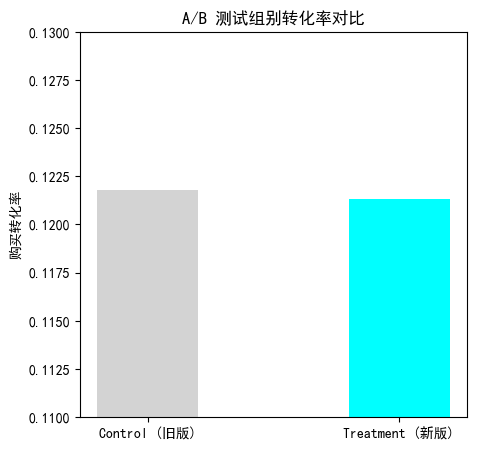

In [15]:
# 全局配置支持中文的字体和负号显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签（黑体）
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号

plt.figure(figsize=(5, 5))
plt.bar(['Control (旧版)', 'Treatment (新版)'], conv_summary['mean'], width=0.4, color=['lightgray', 'cyan'])
plt.title('A/B 测试组别转化率对比', fontsize=12)
plt.ylabel('购买转化率')
plt.ylim(0.11, 0.13)
plt.show()